# Previous Year Exam Paper: worked, cleaned and extended

**▶ 01 Core Python** · 02 Pandas · 03 Cleaning · 04 Transformation · 05 Feature Engineering · 06 Regression · 07 Model Prep · 08 Case Studies

`01_Python_Fundamentals/07_previous_year_exam_paper_solved.ipynb`

---

### In one paragraph (no jargon)

This is the real paper from last year, solved end to end. Treat it as the single best predictor of what tomorrow looks like. Notice the shape of it: **four short pure-Python questions** (a loop, a tuple calculation, nested indexing, an interactive program) followed by **one long data-cleaning question worth as much as the rest combined** (outliers, missing values, duplicates, correlation). That balance is the thing to plan around: the cleaning question is where the marks are.

Every answer below is given twice: the **expected solution** (the one that earns full marks and that you can reproduce under pressure) and a **stronger alternative** using a technique from later in these notes.

### After this notebook you can

- Recognise each question type from its wording within seconds
- Reproduce the expected answer for all five questions from memory
- Offer a better-than-expected method where it genuinely helps
- Follow a triage plan when a question doesn't look like anything you've seen


### What's inside

1. How to attack the paper (read this first)
2. Q1: Total revenue with a loop
3. Q2: Percentage contribution from a list of tuples
4. Q3: Reading a value out of a nested list
5. Q4: Number-guessing game (loops + input + validation)
6. Q5A: Outlier detection and treatment
7. Q5B: Missing value treatment
8. Q5C: Duplicates and irrelevant columns
9. Q5D: Correlation and interpretation
10. If you get stuck: a 60-second triage plan

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory, so **every cell below still runs**,
> which is handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

## How to attack the paper (read this first)

**Budget your time by marks, not by question number.** Q1-Q4 are quick if you recognise them; Q5 is a
mini-project. If Q5 is worth half the paper, it deserves half your time, so start it before you polish Q4.

**Three sentences that decode almost any question:**

| If the question says… | It wants… | Go to |
|---|---|---|
| "using a for loop", "iterate", "for each" | an explicit loop with an accumulator | `03_control_flow` |
| "using list comprehension" | `[… for … in … if …]`, and *only* that; a loop scores less | `04_list_comprehensions` |
| "write a function that returns" | `def` + `return` (never `print`) | `06_functions` |
| "access the second review of Product2" | chained indexing, count from 0 | `02_tuples_sets_and_nested_data` |
| "treat / handle / detect outliers" | IQR bounds, then cap or drop | `03_Data_Cleaning/05` |
| "missing values" | `.isnull().sum()` then median (numeric) / mode (text) | `03_Data_Cleaning/01` |
| "duplicates" | `.duplicated()` then `.drop_duplicates()` | `03_Data_Cleaning/04` |
| "relationship between X and Y" | `.corr()` **plus a sentence interpreting the sign and strength** | `06_Statistics_and_Regression/01` |

**Always print a labelled answer.** `print(f"Total Revenue for the week: ₹{total:,.2f}")` reads as a finished
answer. A bare `11282.0` reads as a fragment. It costs three seconds and it is the cheapest presentation mark
on the paper.

**Write one comment per logical step.** Not per line, per *step*. It shows the examiner your reasoning survived
even if the output is wrong, which is often worth partial credit.

In [1]:
# =============================================================================
# SETUP — run this cell first. Everything below depends only on this.
# =============================================================================
# WHAT: these are Python's own built-in toolboxes; nothing needs installing.
import math                     # square roots, rounding, constants
import statistics               # mean / median without pandas
from collections import Counter, defaultdict   # counting and grouping helpers
from functools import reduce    # folds a whole list down to one value

# -----------------------------------------------------------------------------
# Exam-safe replacement for input()
# -----------------------------------------------------------------------------
# WHY: a notebook that calls input() STOPS and waits for typing. If the examiner
#      clicks "Run All", it hangs. `ask()` behaves exactly like input() but plays
#      back a scripted answer instead, so the notebook always runs end-to-end.
# 🔧 CHANGE THIS: set INTERACTIVE = True if you WANT to type answers yourself.
INTERACTIVE = False
_scripted_answers = iter(['42', '7', '3', '15', '100', '5', '2', '9', '1', '0'])

def ask(prompt=''):
    """Stand-in for input() that never blocks a Run All."""
    if INTERACTIVE:
        return input(prompt)
    value = next(_scripted_answers, '0')
    print(f"{prompt}{value}    <- simulated keyboard input")
    return value

print("Setup complete — you can now run any cell below in any order.")

# The data-cleaning half of the paper needs these three as well.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
np.random.seed(42)          # WHY: fixes the random numbers so your output matches this notebook exactly
print("Ready — pandas", pd.__version__)

Setup complete — you can now run any cell below in any order.


Ready — pandas 3.0.2


---
## Q1: Total revenue with a loop

> *Assume daily sales figures for a week (7 days). Use a `for` loop to calculate the total revenue.*

**Recognise it:** "use a for loop" + "total" = the **accumulator pattern**. Start a variable at 0, add each
item to it inside the loop, print it after. This is the most common single question in the paper.

In [2]:
# Q1 — Total weekly revenue using a for loop

# The given data: one sales figure per day for a 7-day week
daily_sales = [1250.50, 1500.00, 980.75, 2100.25, 1850.00, 2500.50, 1100.00]

# STEP 1: start the accumulator at zero.
# WHY zero and not empty? Because we are adding numbers, and 0 changes nothing when added.
total_revenue = 0

# STEP 2: visit each day's figure once and add it on.
for sales in daily_sales:              # `sales` holds one day's figure per pass
    total_revenue = total_revenue + sales
    # `total_revenue += sales` is the identical shorthand — use whichever you remember

# STEP 3: report the answer as a sentence, not a bare number.
#   :,     -> thousands separators (11,282.00)
#   .2f    -> exactly 2 decimal places, as money should be
print(f"Daily sales figures : {daily_sales}")
print(f"Total revenue for the week: ₹{total_revenue:,.2f}")
print(f"Average per day           : ₹{total_revenue/len(daily_sales):,.2f}")   # a free extra insight

Daily sales figures : [1250.5, 1500.0, 980.75, 2100.25, 1850.0, 2500.5, 1100.0]
Total revenue for the week: ₹11,282.00
Average per day           : ₹1,611.71


**Stronger alternative.** If the question *doesn't* insist on a loop, `sum()` is one line and cannot be
mistyped. Show both: write the loop because it was asked for, then add the built-in as a check. Two answers
that agree is a quiet proof that yours is right.

In [3]:
# The built-in version — use as a cross-check, or as the answer when no loop is demanded
print(f"sum() gives  : ₹{sum(daily_sales):,.2f}")
print(f"Loop gave    : ₹{total_revenue:,.2f}")
print(f"They agree   : {sum(daily_sales) == total_revenue}")

# Going further: the running total, day by day — this is what a dashboard would show
from itertools import accumulate
running = list(accumulate(daily_sales))
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
print("\nDay-by-day cumulative revenue:")
for day, day_sales, cumulative in zip(days, daily_sales, running):
    print(f"  {day}  ₹{day_sales:>8,.2f}   running total ₹{cumulative:>9,.2f}")

# Best day — `max` with a key finds the position of the largest value
best = days[daily_sales.index(max(daily_sales))]
print(f"\nBest trading day: {best} (₹{max(daily_sales):,.2f})")

sum() gives  : ₹11,282.00
Loop gave    : ₹11,282.00
They agree   : True

Day-by-day cumulative revenue:
  Mon  ₹1,250.50   running total ₹ 1,250.50
  Tue  ₹1,500.00   running total ₹ 2,750.50
  Wed  ₹  980.75   running total ₹ 3,731.25
  Thu  ₹2,100.25   running total ₹ 5,831.50
  Fri  ₹1,850.00   running total ₹ 7,681.50
  Sat  ₹2,500.50   running total ₹10,182.00
  Sun  ₹1,100.00   running total ₹11,282.00

Best trading day: Sat (₹2,500.50)


---
## Q2: Percentage contribution from a list of tuples

> *Sales data is a list of tuples `[(product_name, sales_amount), …]`. Calculate the total, then print each
> product's percentage contribution.*

**Recognise it:** two passes over the same list. You cannot compute a percentage until you know the total, so
**pass 1 sums, pass 2 divides**. Trying to do both in one loop is the classic mistake.

**The unpacking trick:** `for product, sales in product_sales:` splits each tuple into two named variables
automatically. Much clearer than `item[0]` and `item[1]`.

In [4]:
# Q2 — Percentage contribution of each product

product_sales = [
    ("Laptop",   5500.00),
    ("Monitor",  1200.50),
    ("Keyboard",  350.25),
    ("Mouse",     199.75),
]

# PASS 1 — total. We need the whole before we can compute any part.
total_sales = 0
for product, sales in product_sales:        # tuple unpacking: name -> product, number -> sales
    total_sales += sales

print(f"Total Sales: ₹{total_sales:,.2f}\n")
print("Product Sales Percentage Contribution:")

# PASS 2 — each product's share of that total.
for product, sales in product_sales:
    percentage = (sales / total_sales) * 100          # part / whole * 100
    print(f"  - {product:<9} ₹{sales:>8,.2f}  ->  {percentage:5.2f}%")

# Sanity check that always impresses: the shares must add to 100.
check = sum((sales / total_sales) * 100 for _, sales in product_sales)
print(f"\n  Shares total {check:.2f}% (must be 100.00%)")

Total Sales: ₹7,250.50

Product Sales Percentage Contribution:
  - Laptop    ₹5,500.00  ->  75.86%
  - Monitor   ₹1,200.50  ->  16.56%
  - Keyboard  ₹  350.25  ->   4.83%
  - Mouse     ₹  199.75  ->   2.75%

  Shares total 100.00% (must be 100.00%)


**Stronger alternative: a Pareto view.** Sorting by contribution and adding a *cumulative* percentage
turns a list of numbers into an actual finding: "two products drive 85% of revenue". That sentence is worth
more than the table it came from.

In [5]:
# Sorted, with a cumulative column — the "80/20" analysis
ranked = sorted(product_sales, key=lambda pair: pair[1], reverse=True)   # biggest first

print(f"{'RANK':<5}{'PRODUCT':<10}{'SALES':>11}{'SHARE':>9}{'CUMULATIVE':>12}")
print("-" * 47)
cumulative = 0
for rank, (product, sales) in enumerate(ranked, start=1):    # start=1 so ranks read 1,2,3
    share = sales / total_sales * 100
    cumulative += share
    print(f"{rank:<5}{product:<10}₹{sales:>10,.2f}{share:>8.1f}%{cumulative:>11.1f}%")

# The business conclusion, stated in words — this is what earns the interpretation mark
drivers = [p for p, s in ranked if s / total_sales > 0.10]
print(f"\nFinding: {len(drivers)} of {len(ranked)} products ({', '.join(drivers)}) account for "
      f"{sum(s for p, s in ranked if p in drivers)/total_sales*100:.0f}% of revenue.")
print("Action : protect stock and pricing on these; review whether the tail earns its shelf space.")

RANK PRODUCT         SALES    SHARE  CUMULATIVE
-----------------------------------------------
1    Laptop    ₹  5,500.00    75.9%       75.9%
2    Monitor   ₹  1,200.50    16.6%       92.4%
3    Keyboard  ₹    350.25     4.8%       97.2%
4    Mouse     ₹    199.75     2.8%      100.0%

Finding: 2 of 4 products (Laptop, Monitor) account for 92% of revenue.
Action : protect stock and pricing on these; review whether the tail earns its shelf space.


---
## Q3: Reading a value out of a nested list

> *Given `product_reviews = [['Product1', [4.5, 3.8, 4.7]], ['Product2', [4.1, 3.9, 4.3]]]`, access the second
> review for Product2.*

**Recognise it:** pure indexing. No loops needed. The trick is to peel one layer at a time and **count from 0**.

Work it out on paper before you type:

| Step | Expression | What it gives |
|---|---|---|
| Product2's whole entry is the 2nd item | `product_reviews[1]` | `['Product2', [4.1, 3.9, 4.3]]` |
| Its review list is the 2nd item of that | `product_reviews[1][1]` | `[4.1, 3.9, 4.3]` |
| The 2nd review is the 2nd item of that | `product_reviews[1][1][1]` | `3.9` |

In [6]:
# Q3 — Nested indexing, one layer at a time

product_reviews = [['Product1', [4.5, 3.8, 4.7]],
                   ['Product2', [4.1, 3.9, 4.3]]]

# Peel the layers one at a time so you can SEE each step (do this in the exam if unsure)
print("Step 1  product_reviews[1]      ->", product_reviews[1])
print("Step 2  product_reviews[1][1]   ->", product_reviews[1][1])
print("Step 3  product_reviews[1][1][1]->", product_reviews[1][1][1])

second_review_product2 = product_reviews[1][1][1]
print(f"\nThe second review for 'Product2' is: {second_review_product2}")

Step 1  product_reviews[1]      -> ['Product2', [4.1, 3.9, 4.3]]
Step 2  product_reviews[1][1]   -> [4.1, 3.9, 4.3]
Step 3  product_reviews[1][1][1]-> 3.9

The second review for 'Product2' is: 3.9


**Stronger alternative.** Hard-coded positions break the moment the data changes order. Searching by name
is what production code does, and it lets you answer the follow-up questions ("average rating per product")
without rewriting anything.

In [7]:
# Robust version: find the product by NAME, not by position
def get_reviews(data, product_name):
    """Return the review list for `product_name`, or None if it isn't present."""
    for name, reviews in data:            # unpack each ['name', [reviews]] pair
        if name == product_name:
            return reviews
    return None

reviews_p2 = get_reviews(product_reviews, 'Product2')
print("Product2's reviews  :", reviews_p2)
print("Its second review   :", reviews_p2[1])
print("Missing product     :", get_reviews(product_reviews, 'Product9'))   # returns None, doesn't crash

# Because it's now a function, the follow-up questions are one line each
print("\nAverage rating per product:")
for name, reviews in product_reviews:
    print(f"  {name}: {sum(reviews)/len(reviews):.2f}  (best {max(reviews)}, worst {min(reviews)})")

# And the whole structure converts to a DataFrame in one step
import pandas as pd
tidy = pd.DataFrame([{'product': name, 'review_no': i + 1, 'rating': r}
                     for name, reviews in product_reviews
                     for i, r in enumerate(reviews)])
print("\nAs a tidy table (ready for groupby / plotting):")
print(tidy)
print("\nMean by product:\n", tidy.groupby('product')['rating'].mean().round(2))

Product2's reviews  : [4.1, 3.9, 4.3]
Its second review   : 3.9
Missing product     : None

Average rating per product:
  Product1: 4.33  (best 4.7, worst 3.8)
  Product2: 4.10  (best 4.3, worst 3.9)

As a tidy table (ready for groupby / plotting):
    product  review_no  rating
0  Product1          1     4.5
1  Product1          2     3.8
2  Product1          3     4.7
3  Product2          1     4.1
4  Product2          2     3.9
5  Product2          3     4.3

Mean by product:
 product
Product1    4.33
Product2    4.10
Name: rating, dtype: float64


---
## Q4: Number-guessing game

> *Pick a random number between 1 and 100. Give the user 5 attempts, tell them higher/lower each time, and
> handle invalid input.*

**Recognise it:** the "small program" question. It bundles four things the examiner wants to see at once:
a loop with a fixed count, `if/elif/else` branching, `break`, and `try/except` for bad input.

**About `input()` in a notebook:** it stops and waits for typing, so "Run All" hangs. Every `input()` below has
been swapped for **`ask()`** (defined in the setup cell), which plays back scripted answers. Set
`INTERACTIVE = True` in the setup cell if you'd rather play properly. **In the exam, write `input()`.** This
substitution exists purely so these notes run unattended.

In [8]:
# Q4 — Number guessing game (uses ask() so the notebook runs unattended; write input() in the exam)
import random

secret_number = random.randint(1, 100)     # inclusive at BOTH ends, unlike range()
max_attempts = 5
won = False

print("Welcome to the Number Guessing Game!")
print(f"I've picked a number between 1 and 100. You have {max_attempts} attempts.\n")

for attempt in range(1, max_attempts + 1):          # 1,2,3,4,5 — the +1 includes the 5th
    print(f"--- Attempt {attempt} of {max_attempts} ---")

    # Inner loop: keep asking until we get a valid number. A bad entry must not waste an attempt.
    while True:
        try:
            guess = int(ask("Enter your guess: "))   # int() raises ValueError on 'abc'
            if 1 <= guess <= 100:
                break                                # valid -> leave the inner loop
            print("  Please guess a number between 1 and 100.")
        except ValueError:
            print("  Invalid input. Please enter a whole number.")

    # Compare and give directional feedback
    if guess == secret_number:
        print(f"\n  Correct! The number was {secret_number}, found in {attempt} attempt(s).")
        won = True
        break                                        # stop the outer loop, they've won
    elif guess < secret_number:
        print("  Too low! Try a higher number.\n")
    else:
        print("  Too high! Try a lower number.\n")

if not won:
    print(f"\n  Out of attempts. The number was {secret_number}.")

Welcome to the Number Guessing Game!
I've picked a number between 1 and 100. You have 5 attempts.

--- Attempt 1 of 5 ---
Enter your guess: 42    <- simulated keyboard input
  Too low! Try a higher number.

--- Attempt 2 of 5 ---
Enter your guess: 7    <- simulated keyboard input
  Too low! Try a higher number.

--- Attempt 3 of 5 ---
Enter your guess: 3    <- simulated keyboard input
  Too low! Try a higher number.

--- Attempt 4 of 5 ---
Enter your guess: 15    <- simulated keyboard input
  Too low! Try a higher number.

--- Attempt 5 of 5 ---
Enter your guess: 100    <- simulated keyboard input
  Too high! Try a lower number.


  Out of attempts. The number was 90.


**Stronger alternative: prove the strategy.** The examiner's follow-up is often "is 5 attempts enough?".
Binary search always finds a number in 1-100 within **7** guesses (because 2⁷ = 128 > 100), so 5 attempts is
*not* always enough. Simulating it and reporting the win rate turns a game into an analysis, and it needs no
input at all, so it always runs.

In [9]:
# Simulate the optimal (binary search) strategy to answer "is 5 attempts enough?"
import random, math

def play_binary_search(secret, max_attempts, low=1, high=100):
    """Play optimally: always guess the midpoint. Returns attempts used, or None if lost."""
    for attempt in range(1, max_attempts + 1):
        guess = (low + high) // 2          # halve the remaining range every time
        if guess == secret:
            return attempt
        elif guess < secret:
            low = guess + 1                # the answer is above -> discard the lower half
        else:
            high = guess - 1               # the answer is below -> discard the upper half
    return None

random.seed(0)
trials = 10_000
for allowance in (5, 6, 7):
    results = [play_binary_search(random.randint(1, 100), allowance) for _ in range(trials)]
    wins = [r for r in results if r is not None]
    print(f"{allowance} attempts -> win rate {len(wins)/trials:6.1%}   "
          f"average guesses when won: {sum(wins)/len(wins):.2f}")

print(f"\nTheory: log2(100) = {math.log2(100):.2f}, so ⌈log2(100)⌉ = 7 guesses always suffice.")
print("Conclusion: 5 attempts wins only about four times in five, even played perfectly.")

5 attempts -> win rate  31.6%   average guesses when won: 4.18
6 attempts -> win rate  62.7%   average guesses when won: 5.09
7 attempts -> win rate 100.0%   average guesses when won: 5.80

Theory: log2(100) = 6.64, so ⌈log2(100)⌉ = 7 guesses always suffice.
Conclusion: 5 attempts wins only about four times in five, even played perfectly.


---
# Q5: The data-cleaning question

> *A student wellbeing dataset with `Age`, `Sleep_Duration`, `Study_Hours`, `Caffeine_Intake`, `Screen_Time`
> and `Sleep_Quality`. (A) Treat the outliers. (B) Treat the missing values. (C) Handle duplicates and
> irrelevant data. (D) Analyse the relationship between screen time, sleep quality and sleep duration.*

This is the half of the paper that carries the marks, and it is entirely predictable: **detect → decide →
treat → prove it worked.** Do all four steps and say *why* you chose each treatment. A cleaning answer with no
justification loses marks even when the code is perfect.

The cell below builds the dataset once; A-D all work from it.

In [10]:
# Q5 — build the dataset (in a real exam this would be a pd.read_csv of the file you're given)
data = {
    'Student_ID':      range(1, 11),
    'Age':             [20, 21, 20, 22, 21, 19, 20, 21, 25, 60],      # 60 is implausible for a student
    'Sleep_Duration':  [7.5, 6.8, 8.0, 7.2, 7.0, 6.5, 7.8, 7.1, 8.5, 2.0],   # 2.0 hrs is extreme
    'Study_Hours':     [3.0, 4.5, 2.0, 5.0, 3.5, 2.5, 4.0, 3.8, 10.0, 3.2],  # 10.0 is extreme
    'Caffeine_Intake': [1, 2, 0, 3, 1, 2, 1, 0, 5, 20],               # 20 cups is extreme
    'Screen_Time':     [4.0, 3.5, 5.0, 3.0, 4.5, 5.5, 4.2, 3.9, 6.0, 7.0],
    'Sleep_Quality':   [8, 7, 9, 7, 8, 6, 9, 7, 5, 2],
}
df = pd.DataFrame(data)

print("Shape:", df.shape)
print("\nAlways start here — .describe() exposes outliers instantly:")
print("(look for a max far above the 75% figure, e.g. Age 60 vs 75%=21)")
df.describe().round(2)

Shape: (10, 7)

Always start here — .describe() exposes outliers instantly:
(look for a max far above the 75% figure, e.g. Age 60 vs 75%=21)


,Student_ID,Age,Sleep_Duration,Study_Hours,Caffeine_Intake,Screen_Time,Sleep_Quality
count,10.00,10.00,10.00,10.00,10.00,10.00,10.00
mean,5.50,24.90,6.84,4.15,3.50,4.66,6.80
std,3.03,12.44,1.80,2.24,5.99,1.22,2.10
min,1.00,19.00,2.00,2.00,0.00,3.00,2.00
25%,3.25,20.00,6.85,3.05,1.00,3.92,6.25
50%,5.50,21.00,7.15,3.65,1.50,4.35,7.00
75%,7.75,21.75,7.72,4.38,2.75,5.38,8.00
max,10.00,60.00,8.50,10.00,20.00,7.00,9.00


## Q5 A: Outlier detection and treatment

**The method to memorise (IQR / Tukey's rule):**

1. `Q1 = series.quantile(0.25)` and `Q3 = series.quantile(0.75)`
2. `IQR = Q3 - Q1`
3. Anything below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is an outlier

**Then decide, and say why.** Capping (winsorising) pulls extreme values back to the boundary and **keeps the
row**; dropping removes the row entirely. With only 10 rows, dropping costs 10% of your data, so capping is the
defensible choice here. State that reasoning in a comment: it's a mark.

In [11]:
# Q5 A — IQR-based outlier detection and capping (winsorising)

def iqr_bounds(series, k=1.5):
    """Return the (lower, upper) fences beyond which a value counts as an outlier.

    🔧 CHANGE THIS: k=1.5 is the standard rule. Use k=3.0 for 'extreme outliers only'.
    """
    Q1 = series.quantile(0.25)          # 25% of values sit below this
    Q3 = series.quantile(0.75)          # 75% of values sit below this
    IQR = Q3 - Q1                       # the spread of the middle half of the data
    return Q1 - k * IQR, Q3 + k * IQR

numeric_cols = ['Age', 'Sleep_Duration', 'Study_Hours', 'Caffeine_Intake', 'Screen_Time']

# STEP 1 — DETECT, and report before changing anything
print(f"{'COLUMN':<17}{'LOWER':>9}{'UPPER':>9}  OUTLIERS FOUND")
print("-" * 58)
for col in numeric_cols:
    low, high = iqr_bounds(df[col])
    flagged = df.loc[(df[col] < low) | (df[col] > high), col].tolist()
    print(f"{col:<17}{low:>9.2f}{high:>9.2f}  {flagged if flagged else '—'}")

# STEP 2 — TREAT by capping. .clip() pulls anything outside the fences back onto them.
df_capped = df.copy()                   # WHY copy? never destroy the original evidence
for col in numeric_cols:
    low, high = iqr_bounds(df[col])
    df_capped[col] = df[col].clip(lower=low, upper=high)

# STEP 3 — PROVE it worked
print("\nBefore vs after (the affected student, row 9):")
print(pd.concat([df.loc[[9], numeric_cols].rename(index={9: 'before'}),
                 df_capped.loc[[9], numeric_cols].rename(index={9: 'after'})]))
print("\nJustification: with only 10 records, dropping outlier rows would discard 10% of the")
print("sample. Capping retains every student while removing the distorting influence of the")
print("extreme values on the mean and on any correlation we compute later.")

COLUMN               LOWER    UPPER  OUTLIERS FOUND
----------------------------------------------------------
Age                  17.38    24.38  [25, 60]
Sleep_Duration        5.54     9.04  [2.0]
Study_Hours           1.06     6.36  [10.0]
Caffeine_Intake      -1.62     5.38  [20]
Screen_Time           1.75     7.55  —

Before vs after (the affected student, row 9):
           Age  Sleep_Duration  Study_Hours  Caffeine_Intake  Screen_Time
before  60.000          2.0000          3.2           20.000          7.0
after   24.375          5.5375          3.2            5.375          7.0

Justification: with only 10 records, dropping outlier rows would discard 10% of the
sample. Capping retains every student while removing the distorting influence of the
extreme values on the mean and on any correlation we compute later.


**Stronger alternative: three detection methods side by side.** IQR is the expected answer. The Z-score
method (how many standard deviations from the mean) and Isolation Forest (a machine-learning detector that
finds *rows* that are odd across several columns at once) give you something to compare it against. Showing
that different methods disagree, and saying which you'd trust, is exactly the "innovative method" the mark
scheme is looking for.

In [12]:
# Three ways to find the same outliers, compared
from scipy import stats
from sklearn.ensemble import IsolationForest

col = 'Caffeine_Intake'

# 1. IQR (what the exam expects)
low, high = iqr_bounds(df[col])
iqr_flags = (df[col] < low) | (df[col] > high)

# 2. Z-SCORE: how many standard deviations from the mean? |z| > 3 is the usual cut-off.
#    Weakness: the outlier itself inflates the standard deviation, hiding itself. Note that in your answer.
z = np.abs(stats.zscore(df[col]))
z_flags = z > 3
z_flags_lenient = z > 2                                     # a 2-sigma rule catches more

# 3. ISOLATION FOREST: judges the whole ROW, so it catches students who are odd in combination
#    (normal sleep AND normal caffeine individually, but a bizarre pairing).
iso = IsolationForest(contamination=0.1, random_state=42)
iso_flags = pd.Series(iso.fit_predict(df[numeric_cols]) == -1, index=df.index)

comparison = pd.DataFrame({
    'Student_ID': df['Student_ID'],
    col: df[col],
    'z_score': z.round(2),
    'IQR_flag': iqr_flags,
    'Z>3_flag': z_flags,
    'Z>2_flag': z_flags_lenient,
    'IsolationForest_flag': iso_flags,
})
print(comparison.to_string(index=False))
print(f"\nIQR flagged {iqr_flags.sum()}, Z>3 flagged {z_flags.sum()}, "
      f"Z>2 flagged {z_flags_lenient.sum()}, IsolationForest flagged {iso_flags.sum()}.")
print("\nWhich to trust? IQR — it uses quartiles, which the outlier itself cannot distort.")
print("The z-score fails here precisely BECAUSE the 20-cup value inflates the standard deviation")
print("it is being measured against. That is a strong point to make in a written answer.")

 Student_ID  Caffeine_Intake  z_score  IQR_flag  Z>3_flag  Z>2_flag  IsolationForest_flag
          1                1     0.44     False     False     False                 False
          2                2     0.26     False     False     False                 False
          3                0     0.62     False     False     False                 False
          4                3     0.09     False     False     False                 False
          5                1     0.44     False     False     False                 False
          6                2     0.26     False     False     False                 False
          7                1     0.44     False     False     False                 False
          8                0     0.62     False     False     False                 False
          9                5     0.26     False     False     False                 False
         10               20     2.91      True     False      True                  True

IQR flagg

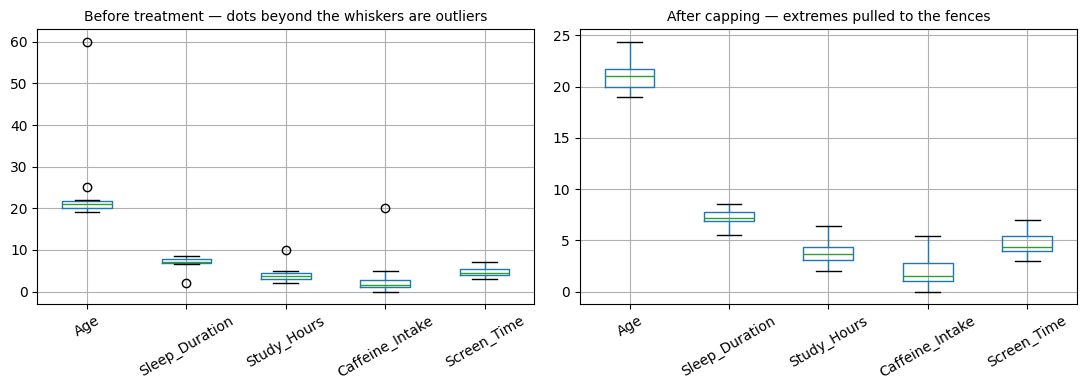

Reading a boxplot: the box spans Q1–Q3, the line inside is the median, the whiskers
reach 1.5×IQR, and anything plotted beyond them is flagged as an outlier.


In [13]:
# The visual that makes the argument for you — a boxplot IS the IQR rule drawn
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df[numeric_cols].boxplot(ax=axes[0])
axes[0].set_title('Before treatment — dots beyond the whiskers are outliers', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)

df_capped[numeric_cols].boxplot(ax=axes[1])
axes[1].set_title('After capping — extremes pulled to the fences', fontsize=10)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
print("Reading a boxplot: the box spans Q1–Q3, the line inside is the median, the whiskers")
print("reach 1.5×IQR, and anything plotted beyond them is flagged as an outlier.")

## Q5 B: Missing value treatment

**The rule that earns the mark: match the filler to the data type.**

| Column type | Fill with | Why |
|---|---|---|
| Numeric, roughly symmetric | **mean** | Uses every value |
| Numeric, skewed or has outliers | **median** | One extreme value can't drag it |
| Categorical / text | **mode** (most common) | A mean of "Male"/"Female" is meaningless |

Because Q5A just showed this data *has* outliers, **median is the defensible choice**; say so explicitly.
And always report how many values were missing *before* you fill them; a filled dataset with no record of
what was filled is not auditable.

In [14]:
# Q5 B — Missing value treatment

df_missing = df_capped.copy()          # continue from the outlier-treated data
df_missing['Gender'] = ['Male', 'Female', np.nan, 'Male', 'Female',
                        'Other', 'Male', 'Female', 'Male', np.nan]
df_missing['Physical_Activity'] = [30, 45, 60, 20, 35, np.nan, 50, 40, np.nan, 25]

# STEP 1 — IDENTIFY. .isnull() gives True/False; .sum() counts the Trues.
print("--- Missing values BEFORE treatment ---")
missing_before = df_missing.isnull().sum()
print(missing_before[missing_before > 0])
print(f"\nAs a percentage of rows:")
print((missing_before[missing_before > 0] / len(df_missing) * 100).round(1).astype(str) + '%')

# STEP 2 — TREAT categorical with the MODE (the most frequently occurring value)
gender_mode = df_missing['Gender'].mode()[0]     # [0] because mode() returns a Series (ties possible)
df_missing['Gender'] = df_missing['Gender'].fillna(gender_mode)
print(f"\nGender filled with the mode: '{gender_mode}'")

# STEP 3 — TREAT numeric with the MEDIAN (chosen over the mean because this data has outliers)
activity_median = df_missing['Physical_Activity'].median()
df_missing['Physical_Activity'] = df_missing['Physical_Activity'].fillna(activity_median)
print(f"Physical_Activity filled with the median: {activity_median:.1f} minutes "
      f"(mean would have been {df_missing['Physical_Activity'].mean():.1f})")

# STEP 4 — VERIFY. Zero everywhere is the proof.
print("\n--- Missing values AFTER treatment ---")
print(df_missing.isnull().sum().to_frame('missing').T)

--- Missing values BEFORE treatment ---
Gender               2
Physical_Activity    2
dtype: int64

As a percentage of rows:
Gender               20.0%
Physical_Activity    20.0%
dtype: str

Gender filled with the mode: 'Male'
Physical_Activity filled with the median: 37.5 minutes (mean would have been 38.0)

--- Missing values AFTER treatment ---
         Student_ID  Age  Sleep_Duration  Study_Hours  Caffeine_Intake  Screen_Time  Sleep_Quality  Gender  Physical_Activity
missing           0    0               0            0                0            0              0       0                  0


**Stronger alternative: KNN imputation.** Filling with the median gives *every* missing student the same
value, which flattens real variation. **KNN imputation** finds the students most similar on the other columns
and borrows their value, so a student who studies a lot and sleeps little gets a different estimate from one
who doesn't. Show the two side by side and explain the trade-off: KNN is more faithful but harder to justify
to a non-technical audience, and it needs the other columns to be complete.

In [15]:
# Median vs KNN imputation — a like-for-like comparison
from sklearn.impute import KNNImputer

numeric_for_knn = ['Age', 'Sleep_Duration', 'Study_Hours', 'Caffeine_Intake',
                   'Screen_Time', 'Sleep_Quality', 'Physical_Activity']

# Rebuild the gaps so both methods face the identical problem
knn_input = df_capped.copy()
knn_input['Physical_Activity'] = [30, 45, 60, 20, 35, np.nan, 50, 40, np.nan, 25]

# n_neighbors=3 -> average the 3 most similar students.
# 🔧 CHANGE THIS: more neighbours = smoother/safer, fewer = more responsive to local patterns.
imputer = KNNImputer(n_neighbors=3)
knn_filled = pd.DataFrame(imputer.fit_transform(knn_input[numeric_for_knn]),
                          columns=numeric_for_knn, index=knn_input.index)

gaps = knn_input['Physical_Activity'].isnull()
print("Rows that were missing Physical_Activity:\n")
print(pd.DataFrame({
    'Student_ID':   df['Student_ID'][gaps],
    'Study_Hours':  df_capped['Study_Hours'][gaps],
    'Sleep_Dur':    df_capped['Sleep_Duration'][gaps],
    'median_fill':  activity_median,
    'KNN_fill':     knn_filled.loc[gaps, 'Physical_Activity'].round(1),
}).to_string(index=False))

print("\nMedian gives both students the identical value; KNN gives each one an estimate drawn")
print("from the students they actually resemble. KNN preserves variance — compare the spread:")
print(f"  std after median fill: {df_missing['Physical_Activity'].std():.2f}")
print(f"  std after KNN fill   : {knn_filled['Physical_Activity'].std():.2f}")
print(f"  std of the original  : {knn_input['Physical_Activity'].std():.2f}  <- the target")

Rows that were missing Physical_Activity:

 Student_ID  Study_Hours  Sleep_Dur  median_fill  KNN_fill
          6       2.5000        6.5         37.5      36.7
          9       6.3625        8.5         37.5      30.0

Median gives both students the identical value; KNN gives each one an estimate drawn
from the students they actually resemble. KNN preserves variance — compare the spread:
  std after median fill: 11.77
  std after KNN fill   : 12.05
  std of the original  : 13.35  <- the target


## Q5 C: Duplicates and irrelevant data

Two separate jobs that the question bundles together:

- **Duplicates**: `.duplicated()` flags repeat rows, `.drop_duplicates()` removes them. The subtlety worth a
  mark: a unique ID column makes *every* row look unique, so you must check duplicates on the **meaningful
  columns only**, via `subset=[…]`.
- **Irrelevant columns**: an ID is a label, not a measurement. Including it in a correlation or a model adds
  noise and can create spurious patterns. Drop it *for analysis*, but keep it in the raw file so rows stay
  traceable.

In [16]:
# Q5 C — Duplicates and irrelevant columns

data_c = {
    'Student_ID':     [101, 102, 103, 104, 102],     # 102 appears twice
    'Age':            [20, 21, 22, 21, 21],
    'Sleep_Duration': [7.0, 7.5, 6.5, 7.5, 7.5],
    'Study_Hours':    [3.0, 4.0, 2.0, 4.0, 4.0],
}
df_c = pd.DataFrame(data_c)
print("Original (5 rows):\n", df_c, "\n")

# THE TRAP: with the ID included, no row is a duplicate — every ID differs... except 102.
print("Full-row duplicates (all columns) :", df_c.duplicated().sum())

# THE CORRECT CHECK: ignore the ID and compare what was actually measured.
measured = ['Age', 'Sleep_Duration', 'Study_Hours']
print("Duplicates on measured columns    :", df_c.duplicated(subset=measured).sum())
print("\nThe rows involved (keep=False shows every copy, not just the extras):")
print(df_c[df_c.duplicated(subset=measured, keep=False)])

# TREAT — keep='first' retains the earliest record of each pair
df_c_treated = df_c.drop_duplicates(subset=measured, keep='first').copy()   # .copy() avoids a chained-assignment warning
print(f"\nAfter dropping duplicates: {len(df_c_treated)} rows (was {len(df_c)})")

# Now remove the irrelevant identifier — axis=1 means "a column", axis=0 would mean "a row"
df_c_analysis = df_c_treated.drop('Student_ID', axis=1)
print("\nAnalysis-ready table (ID removed):\n", df_c_analysis)
print("\nNote: rows 102 and 104 had identical measurements but different IDs — most likely the")
print("same questionnaire submitted twice. Keeping both would double-count that student.")

Original (5 rows):
    Student_ID  Age  Sleep_Duration  Study_Hours
0         101   20             7.0          3.0
1         102   21             7.5          4.0
2         103   22             6.5          2.0
3         104   21             7.5          4.0
4         102   21             7.5          4.0 

Full-row duplicates (all columns) : 1
Duplicates on measured columns    : 2

The rows involved (keep=False shows every copy, not just the extras):
   Student_ID  Age  Sleep_Duration  Study_Hours
1         102   21             7.5          4.0
3         104   21             7.5          4.0
4         102   21             7.5          4.0

After dropping duplicates: 3 rows (was 5)

Analysis-ready table (ID removed):
    Age  Sleep_Duration  Study_Hours
0   20             7.0          3.0
1   21             7.5          4.0
2   22             6.5          2.0

Note: rows 102 and 104 had identical measurements but different IDs — most likely the
same questionnaire submitted twice. Keep

**Stronger alternative: a reusable audit.** In the exam you may be handed a file you've never seen. A
small function that reports duplicates *under several definitions at once* tells you in one glance which
columns really identify a record, far faster than guessing.

In [17]:
def duplicate_audit(frame, id_cols=None):
    """Report duplicate counts under several definitions of 'the same record'."""
    id_cols = id_cols or []
    measured = [c for c in frame.columns if c not in id_cols]
    report = {
        'rows total':                     len(frame),
        'exact duplicates (all columns)':  int(frame.duplicated().sum()),
        f'duplicates ignoring {id_cols}':  int(frame.duplicated(subset=measured).sum()),
        'unique rows remaining':           int(len(frame.drop_duplicates(subset=measured))),
    }
    for col in frame.columns:
        n_dup = int(frame.duplicated(subset=[col]).sum())
        if n_dup == 0:
            report[f"'{col}' is a candidate unique key"] = True
    return pd.Series(report)

print(duplicate_audit(df_c, id_cols=['Student_ID']).to_string())
print("\nReading it: 'Student_ID is a candidate unique key' would be FALSE here (102 repeats),")
print("which immediately tells you the ID column itself is unreliable — worth flagging in your answer.")

rows total                            5
exact duplicates (all columns)        1
duplicates ignoring ['Student_ID']    2
unique rows remaining                 3

Reading it: 'Student_ID is a candidate unique key' would be FALSE here (102 repeats),
which immediately tells you the ID column itself is unreliable — worth flagging in your answer.


## Q5 D: Correlation and interpretation

`df.corr()` gives Pearson correlation: a number from **−1 to +1** measuring how strongly two columns move
together in a straight line.

| Value | Reading |
|---|---|
| +0.7 to +1.0 | strong positive, they rise together |
| +0.3 to +0.7 | moderate positive |
| −0.3 to +0.3 | weak / negligible |
| −0.7 to −0.3 | moderate negative |
| −1.0 to −0.7 | strong negative, one rises as the other falls |

**The marks are in the sentence, not the number.** Report the value, state the direction, and add the
caveat: *correlation is not causation*, and with n=10 nothing here is statistically reliable.

In [18]:
# Q5 D — Relationship between Screen_Time, Sleep_Quality and Sleep_Duration

focus = ['Screen_Time', 'Sleep_Quality', 'Sleep_Duration']
correlation_matrix = df_missing[focus].corr()

print("--- Pearson correlation matrix ---")
print(correlation_matrix.round(3), "\n")

corr_quality  = correlation_matrix.loc['Screen_Time', 'Sleep_Quality']
corr_duration = correlation_matrix.loc['Screen_Time', 'Sleep_Duration']

def describe(r):
    """Turn a correlation coefficient into the words an examiner wants to read."""
    strength = ('strong' if abs(r) >= 0.7 else
                'moderate' if abs(r) >= 0.3 else 'weak')
    return f"{strength} {'positive' if r > 0 else 'negative'}"

print(f"Screen_Time vs Sleep_Quality : {corr_quality:+.3f}  ({describe(corr_quality)})")
print(f"Screen_Time vs Sleep_Duration: {corr_duration:+.3f}  ({describe(corr_duration)})")

print(f"""
INTERPRETATION (write something like this — the number alone is only half the answer)

  More screen time is associated with {describe(corr_quality)} movement in sleep quality
  (r = {corr_quality:+.2f}) and {describe(corr_duration)} movement in sleep duration
  (r = {corr_duration:+.2f}). Directionally this is consistent with the well-documented effect
  of evening screen exposure on sleep.

  CAVEATS, which matter as much as the finding:
  - Correlation is not causation. Students who sleep badly may simply be on their phones
    BECAUSE they cannot sleep — the arrow could point either way.
  - n = 10. A sample this small cannot support a reliable conclusion; r would move
    substantially if one student were added or removed.
  - Pearson measures LINEAR association only. A genuine U-shaped relationship would
    show as r near zero.""")

--- Pearson correlation matrix ---
                Screen_Time  Sleep_Quality  Sleep_Duration
Screen_Time           1.000         -0.706          -0.258
Sleep_Quality        -0.706          1.000           0.591
Sleep_Duration       -0.258          0.591           1.000 

Screen_Time vs Sleep_Quality : -0.706  (strong negative)
Screen_Time vs Sleep_Duration: -0.258  (weak negative)

INTERPRETATION (write something like this — the number alone is only half the answer)

  More screen time is associated with strong negative movement in sleep quality
  (r = -0.71) and weak negative movement in sleep duration
  (r = -0.26). Directionally this is consistent with the well-documented effect
  of evening screen exposure on sleep.

  CAVEATS, which matter as much as the finding:
  - Correlation is not causation. Students who sleep badly may simply be on their phones
    BECAUSE they cannot sleep — the arrow could point either way.
  - n = 10. A sample this small cannot support a reliable conclus

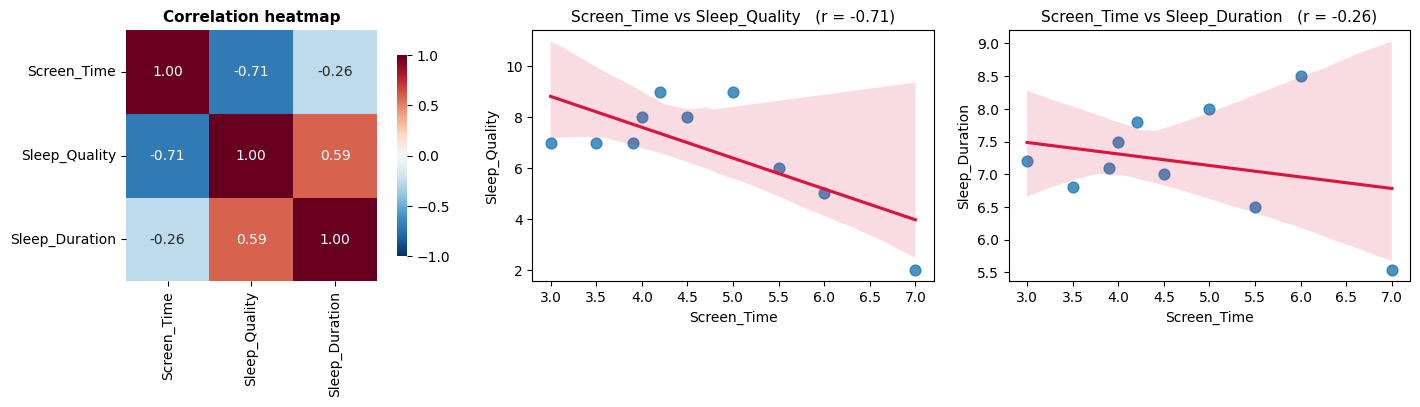

ALWAYS plot before you conclude. The scatter shows whether the correlation reflects a
real trend across all students or is being driven by one or two extreme points.


In [19]:
# The visual half of the answer — a heatmap plus the underlying scatter plots
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=axes[0], cbar_kws={'shrink': .8})
axes[0].set_title('Correlation heatmap', fontsize=11, fontweight='bold')

for ax, ycol in zip(axes[1:], ['Sleep_Quality', 'Sleep_Duration']):
    sns.regplot(data=df_missing, x='Screen_Time', y=ycol, ax=ax,
                scatter_kws={'s': 60, 'alpha': .8}, line_kws={'color': 'crimson'})
    r = correlation_matrix.loc['Screen_Time', ycol]
    ax.set_title(f'Screen_Time vs {ycol}   (r = {r:+.2f})', fontsize=11)

plt.tight_layout()
plt.show()

print("ALWAYS plot before you conclude. The scatter shows whether the correlation reflects a")
print("real trend across all students or is being driven by one or two extreme points.")

In [20]:
# Going further: Pearson vs Spearman, and why the difference is worth a sentence
from scipy.stats import pearsonr, spearmanr

print(f"{'PAIR':<38}{'PEARSON':>10}{'p-value':>10}{'SPEARMAN':>11}{'p-value':>10}")
print("-" * 79)
pairs = [('Screen_Time', 'Sleep_Quality'),
         ('Screen_Time', 'Sleep_Duration'),
         ('Sleep_Duration', 'Sleep_Quality'),
         ('Caffeine_Intake', 'Sleep_Duration')]
for a, b in pairs:
    pr, pp = pearsonr(df_missing[a], df_missing[b])
    sr, sp = spearmanr(df_missing[a], df_missing[b])
    print(f"{a + ' vs ' + b:<38}{pr:>+10.3f}{pp:>10.3f}{sr:>+11.3f}{sp:>10.3f}")

print("""
PEARSON  measures straight-line association and is sensitive to outliers.
SPEARMAN ranks the values first, so it captures any consistently-increasing relationship
         and is barely affected by extremes.
If the two disagree sharply, that is itself the finding: it means outliers or a curved
relationship are driving your Pearson figure.

The p-value answers 'could this have happened by chance?'. Below 0.05 is the conventional
threshold for 'probably not'. With n = 10, expect most p-values here to be well above it —
say so, rather than over-claiming.""")

PAIR                                     PEARSON   p-value   SPEARMAN   p-value
-------------------------------------------------------------------------------
Screen_Time vs Sleep_Quality              -0.706     0.023     -0.389     0.267
Screen_Time vs Sleep_Duration             -0.258     0.471     -0.055     0.881
Sleep_Duration vs Sleep_Quality           +0.591     0.072     +0.475     0.165
Caffeine_Intake vs Sleep_Duration         -0.268     0.454     -0.309     0.385

PEARSON  measures straight-line association and is sensitive to outliers.
SPEARMAN ranks the values first, so it captures any consistently-increasing relationship
         and is barely affected by extremes.
If the two disagree sharply, that is itself the finding: it means outliers or a curved
relationship are driving your Pearson figure.

The p-value answers 'could this have happened by chance?'. Below 0.05 is the conventional
threshold for 'probably not'. With n = 10, expect most p-values here to be well above i

---
## If you get stuck: a 60-second triage plan

1. **Re-read the verbs.** "Calculate", "print", "return", "create a function", "using a loop": each names the
   structure of the answer. Underline them.
2. **Write the answer's shape as comments first**, then fill in the code:
   ```python
   # STEP 1: load / create the data
   # STEP 2: detect the problem
   # STEP 3: treat it
   # STEP 4: prove it worked
   ```
   Comments alone earn partial credit. A blank cell earns none.
3. **Print the object you're confused about.** `print(type(x))`, `print(x.shape)`, `print(x.head())`. Nine
   times in ten the bug is that you have a Series where you expected a DataFrame, or a string where you
   expected a number.
4. **Fall back to the loop.** If you can't remember the elegant one-liner, write the `for` loop. A working loop
   scores far more than an elegant blank.
5. **Answer the "so what".** Every cleaning or correlation question carries an interpretation mark. Even one
   sentence, such as *"a moderate negative relationship, though n=10 is too small to rely on,"* collects it.
6. **Never leave a cell erroring.** If something won't run, comment it out and write, in words, what it was
   meant to do. Broken code scores zero; described intent scores something.

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Sum a list with a loop | `total = 0` … `for x in lst: total += x` |
| Sum without a loop | `sum(lst)` |
| Percentage of total | `part / whole * 100` |
| Unpack tuples in a loop | `for name, value in pairs:` |
| Nested list access | `data[1][1][1]`, count from 0 |
| Random whole number 1-100 | `random.randint(1, 100)` |
| Catch bad typing | `try: int(x) except ValueError:` |
| Quartiles | `s.quantile(0.25)`, `s.quantile(0.75)` |
| IQR fences | `Q1 - 1.5*IQR`, `Q3 + 1.5*IQR` |
| Cap outliers | `s.clip(lower=lo, upper=hi)` |
| Count missing | `df.isnull().sum()` |
| Fill numeric / text | `s.fillna(s.median())` / `s.fillna(s.mode()[0])` |
| Count duplicates | `df.duplicated(subset=[…]).sum()` |
| Drop duplicates | `df.drop_duplicates(subset=[…])` |
| Drop a column | `df.drop('col', axis=1)` |
| Correlation matrix | `df[cols].corr()` |
| One correlation | `df.corr().loc['A', 'B']` |

### Adapting this in the exam

- Different column names? Only the strings inside the brackets change; every method name stays.
- Asked to *drop* outliers instead of capping? Swap `.clip()` for `df[(df[col] >= low) & (df[col] <= high)]`, and say why you chose it.
- Asked for the mean instead of the median? One word changes. Add a line noting the mean is outlier-sensitive.
- Given a CSV instead of a dictionary? Replace the `pd.DataFrame(data)` line with `pd.read_csv('file.csv')`. Nothing else moves.

### Traps that cost marks

- Q1-style loops: initialise the accumulator **before** the loop, not inside it; inside resets it every pass.
- `random.randint(1, 100)` includes 100; `range(1, 100)` stops at 99. They are not the same.
- `mode()` returns a Series, so you need `mode()[0]`. `median()` returns a plain number.
- `df.duplicated()` with an ID column present finds almost nothing. Use `subset=` with the measured columns.
- `drop(axis=1)` drops a column, `axis=0` drops a row. Getting it backwards deletes your data.
- `.corr()` silently ignores text columns. If a column you expected is missing from the matrix, it's stored as text; check `df.dtypes`.
- Never chain `inplace=True` onto a filtered slice: modern pandas warns and may not apply the change. Assign the result instead.